In [1]:
# notebook to compare bed files of seqlet calls from:
# MPAC
# PARM
# promoterAI

In [4]:
# import packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats
import pybedtools
from collections import Counter
import numpy as np
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import math
import pybedtools
import matplotlib.patches as mpatches

In [5]:
# open the DF of full 250bp promoters
fullPromoters = pd.read_csv('../processed_data/complete.merged.250bp.promoters.exon.filtered.tsv', sep = '\t')['promoter_id'].tolist()

In [6]:
len(fullPromoters)

11670

In [7]:
# open vierstra clusters for collapsing on families instead of tfs
vierstra_motifs = pd.read_excel('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/analyses/gnomad_buffering_analysis/motif_annotations.xlsx', sheet_name=[0,1])
# make a dictionary out of the clusterIDs and Names - this will be used to generate the final dictionary with the motif names
idName_dict = dict(zip(vierstra_motifs[0]['Cluster_ID'], vierstra_motifs[0]['Name']))
# open the second page and assign the Names to the individual motifs
vierstra_motifs[1].loc[:,'cluster_name'] = [idName_dict.get(i) for i in vierstra_motifs[1]['Cluster_ID']]
# make a dictionary that pulls the motif name as a key and returns the vierstra family as a value
vierstra_motif_dict = dict(zip(vierstra_motifs[1]['Motif'], vierstra_motifs[1]['cluster_name']))

In [8]:
# define function for reformatting collapsed mpac seqlet calls:
def mpac_collapsed (path2bed,
                    promoterList,
                    motif_dict):
    # open bed file
    bed = pd.read_csv(path2bed, sep = '\t', header = None)
    # break out gene ids
    bed.loc[:, 'gene_id'] = [i.split('_')[2] for i in bed[3]]
    # filter for only desired promoters
    filtered_bed = bed[bed['gene_id'].isin(promoterList)]
    # reformat the bed for plotting purposes
    bed2plot = pd.DataFrame({'chrom' : filtered_bed[0],
                             'start' : filtered_bed[1],
                             'end' : filtered_bed[2],
                             'tf' : [i.split('_')[0] for i in filtered_bed[4]],
                             'tf_family' : [motif_dict.get(i) for i in filtered_bed[4]],
                             'attribution' : filtered_bed[6],
                             'gene_id' : filtered_bed['gene_id'],
                             'activator_repressor' : filtered_bed[5]})
    return bed2plot

In [9]:
# define function for reformatting parm TANGERMEME tf calls - collapsed
def parmTangermeme_collapsed (path2bed,
                              promoterList,
                              motif_dict):
    # open bed file
    bed = pd.read_csv(path2bed, sep = '\t', header = None)
    # break out gene_ids
    bed.loc[:, 'gene_id'] = [i.split('_')[2] for i in bed[3]]
    # filter for only desired promoters
    filtered_bed = bed[bed['gene_id'].isin(promoterList)]
    # reformat the bed for plotting purposes
    bed2plot = pd.DataFrame({'chrom' : filtered_bed[0],
                             'start' : filtered_bed[1],
                             'end' : filtered_bed[2],
                             'tf' : [i.split('_')[0] for i in filtered_bed[4]],
                             'tf_family' : [motif_dict.get(i) for i in filtered_bed[4]],
                             'attribution' : filtered_bed[6],
                             'gene_id' : filtered_bed['gene_id'],
                             'activator_repressor' : filtered_bed[5]})
    return bed2plot

In [10]:
# define function for reformatting collapsed mpac seqlet calls:
def promoterAI_collapsed (path2bed,
                    promoterList,
                    motif_dict):
    # open bed file
    bed = pd.read_csv(path2bed, sep = '\t', header = None)
    # break out gene ids
    bed.loc[:, 'gene_id'] = [i.split('_')[2] for i in bed[3]]
    # filter for only desired promoters
    filtered_bed = bed[bed['gene_id'].isin(promoterList)]
    # reformat the bed for plotting purposes
    bed2plot = pd.DataFrame({'chrom' : filtered_bed[0],
                             'start' : filtered_bed[1],
                             'end' : filtered_bed[2],
                             'tf' : [i.split('_')[0] for i in filtered_bed[4]],
                             'tf_family' : [motif_dict.get(i) for i in filtered_bed[4]],
                             'attribution' : filtered_bed[6],
                             'gene_id' : filtered_bed['gene_id'],
                             'activator_repressor' : filtered_bed[5]})
    return bed2plot

In [11]:
# define a function for adding necessary columns for plotting comparisons
# we need to consider:
#   the seqlet identification method
#   the seqlet collpsing method
def reformat_seqlets (collapsed,
                      seqlet_method,
                      listOfPromoters,
                      path2bed,
                      motifDict,
                      model):
    ### MPAC ###
    # mpac collapsed
    if collapsed == True and model.upper() == 'MPAC':
        return mpac_collapsed(path2bed, listOfPromoters, motifDict)
    ### PARM ###
    # parm, tangermeme, collapsed
    if collapsed == True and model.upper() == 'PARM' and seqlet_method.upper() == 'TANGERMEME':
        return parmTangermeme_collapsed(path2bed, listOfPromoters, motifDict)
    ### promoterAI ###
    # promoterAI, tangermeme, collapsed
    if collapsed == True and model.upper() == 'PROMOTERAI':
        return promoterAI_collapsed(path2bed, listOfPromoters, motifDict)

In [12]:
# reformat MPAC collapsed BED files
# k562
k_mpac_collapsed = reformat_seqlets(
    True,
    'tangermeme',
    fullPromoters,
    '../processed_data/bed_files/mpac_k562_merged_collapsed_repTFs_112225.bed',
    vierstra_motif_dict,
    'MPAC'
)
# hepg2
h_mpac_collapsed = reformat_seqlets(
    True,
    'tangermeme',
    fullPromoters,
    '../processed_data/bed_files/mpac_hepg2_merged_collapsed_repTFs_112225.bed',
    vierstra_motif_dict,
    'MPAC'
)
# sknsh
s_mpac_collapsed = reformat_seqlets(
    True,
    'tangermeme',
    fullPromoters,
    '../processed_data/bed_files/mpac_sknsh_merged_collapsed_repTFs_112225.bed',
    vierstra_motif_dict,
    'MPAC'
)

In [13]:
k_mpac_collapsed.sample(10)

,chrom,start,end,tf,tf_family,attribution,gene_id,activator_repressor
2747,chr14,56579734,56579744,TEAD1,TEAD,-5.946867,ENSG00000070269.14,Repressor
3915,chr17,39868159,39868166,SP1,KLF/SP/2,8.986121,ENSG00000186075.13,Activator
984,chr1,229558786,229558792,GATA6,GATA,6.669688,ENSG00000135776.5,Activator
5688,chr2,191678105,191678111,ERR2,NR/7,-1.801588,ENSG00000173559.15,Repressor
3060,chr15,49620995,49621003,ZN586,ZNF586,7.811352,ENSG00000104047.15,Activator
5256,chr2,19990201,19990207,NRF1,NRF1,6.409375,ENSG00000118965.16,Activator
861,chr1,201190792,201190801,SNAI1,Ebox/CACCTG,-4.588878,ENSG00000163395.17,Repressor
4914,chr19,44401614,44401625,NRF1,NRF1,14.410430,ENSG00000267173.1,Activator
2341,chr12,104958360,104958365,ZBT14,ZBTB14,5.334627,ENSG00000136052.10,Activator
5375,chr2,47782984,47782991,HIC1,HIC/2,-3.265761,ENSG00000116062.19,Repressor


In [14]:
# save vierstra annotated seqlets to disk
# k_mpac_collapsed.to_csv('../processed_data/bed_files/mpac_k562_merged_collapsed_repTFs_vierstra_clustered.bed', sep = '\t', index = False)
# h_mpac_collapsed.to_csv('../processed_data/bed_files/mpac_hepg2_merged_collapsed_repTFs_vierstra_clustered.bed', sep = '\t', index = False)
# s_mpac_collapsed.to_csv('../processed_data/bed_files/mpac_sknsh_merged_collapsed_repTFs_vierstra_clustered.bed', sep = '\t', index = False)

In [15]:
# reformat PARM, tangermeme call collapsed BED files
# k562
k_parmTangermeme_collapsed = reformat_seqlets(
    True,
    'tangermeme',
    fullPromoters,
    '../processed_data/bed_files/parm_tangermeme_k562_merged_collapsed_repTFs_112225.bed',
    vierstra_motif_dict,
    'PARM'
)
# hepg2
h_parmTangermeme_collapsed = reformat_seqlets(
    True,
    'tangermeme',
    fullPromoters,
    '../processed_data/bed_files/parm_tangermeme_hepg2_merged_collapsed_repTFs_112225.bed',
    vierstra_motif_dict,
    'PARM'
)

In [16]:
# reformat promoterAI tangermeme call collapsed BED files
promoterAI_collapsed = reformat_seqlets(
    True,
    'tangermeme',
    fullPromoters,
    '../processed_data/bed_files/promoterAI_tangermeme_merge_collapsed_repTFs_112225.bed',
    vierstra_motif_dict,
    'promoterAI'
)

In [17]:
def plot_tss_relative_seqlet_positions(seqlets_bed_df, 
                                       promoters_bed_path, 
                                       cell_type, 
                                       cell_color, 
                                       output_path):
    seqlets = pybedtools.BedTool.from_dataframe(seqlets_bed_df.filter(['chrom', 'start', 'end', 'tf_family']))
    promoters = pybedtools.BedTool(promoters_bed_path)
    
    # Intersect to find which seqlets fall within which promoters
    intersection = seqlets.intersect(promoters, wa=True, wb=True)
    
    # The output will have 10 columns: 4 from seqlets + 6 from promoters
    df_intersect = intersection.to_dataframe(names=[
        'seqlet_chrom', 'seqlet_start', 'seqlet_end', 'seqlet_name',
        'promo_chrom', 'promo_start', 'promo_end', 'promo_name', 
        'promo_score', 'promo_strand'
    ])
    
    # Ensure coordinate columns are numeric
    for col in ['seqlet_start', 'seqlet_end', 'promo_start', 'promo_end']:
        df_intersect[col] = pd.to_numeric(df_intersect[col], errors='coerce')
    df_intersect.dropna(inplace=True)

    # Calculate the center of each seqlet
    seqlet_center = (df_intersect['seqlet_start'] + df_intersect['seqlet_end']) / 2

    # Calculate the position relative to the TSS using the strand
    df_intersect['tss_relative_pos'] = np.where(
        df_intersect['promo_strand'] == '+',
        seqlet_center - df_intersect['promo_start'],  # For + strand
        df_intersect['promo_end'] - seqlet_center      # For - strand
    )

    # Plot the distribution of these relative positions
    plt.figure(figsize=(4, 2.5), dpi=300)
    ax = sns.kdeplot(data=df_intersect, x='tss_relative_pos', fill=False, color=cell_color, linewidth=0.75, clip=[0, 250])

    line = ax.lines[0]
    x_data, y_data = line.get_data()

    # 4. Find the maximum density value (max of y_data)
    max_density = np.max(y_data)

    # Optional: find the x-value where the maximum density occurs
    max_x_index = np.argmax(y_data)
    max_x_value = x_data[max_x_index]

    plt.title(f'{cell_type.upper()} | Distribution of Seqlet Positions Relative to TSS', loc='left')
    plt.xlabel('Distance from Transcription Start Site (bp)')
    plt.xticks([0, 50, 100, 150, 200, 250],
               [-250, -200, -150, -100, -50, 0])
    plt.ylabel('Density')
    sns.despine()
    plt.tight_layout()
    #plt.savefig(output_path)
    #plt.close()

    print(f'The max density is {max_density}')
    print(f'The TSS position of the max density is {round(max_x_value - 250, 0)}')
    return df_intersect, (max_x_value, max_density);

The max density is 0.007447281790662783
The TSS position of the max density is -48.0
The max density is 0.0067208678253007515
The TSS position of the max density is -49.0
The max density is 0.006874856011152881
The TSS position of the max density is -20.0


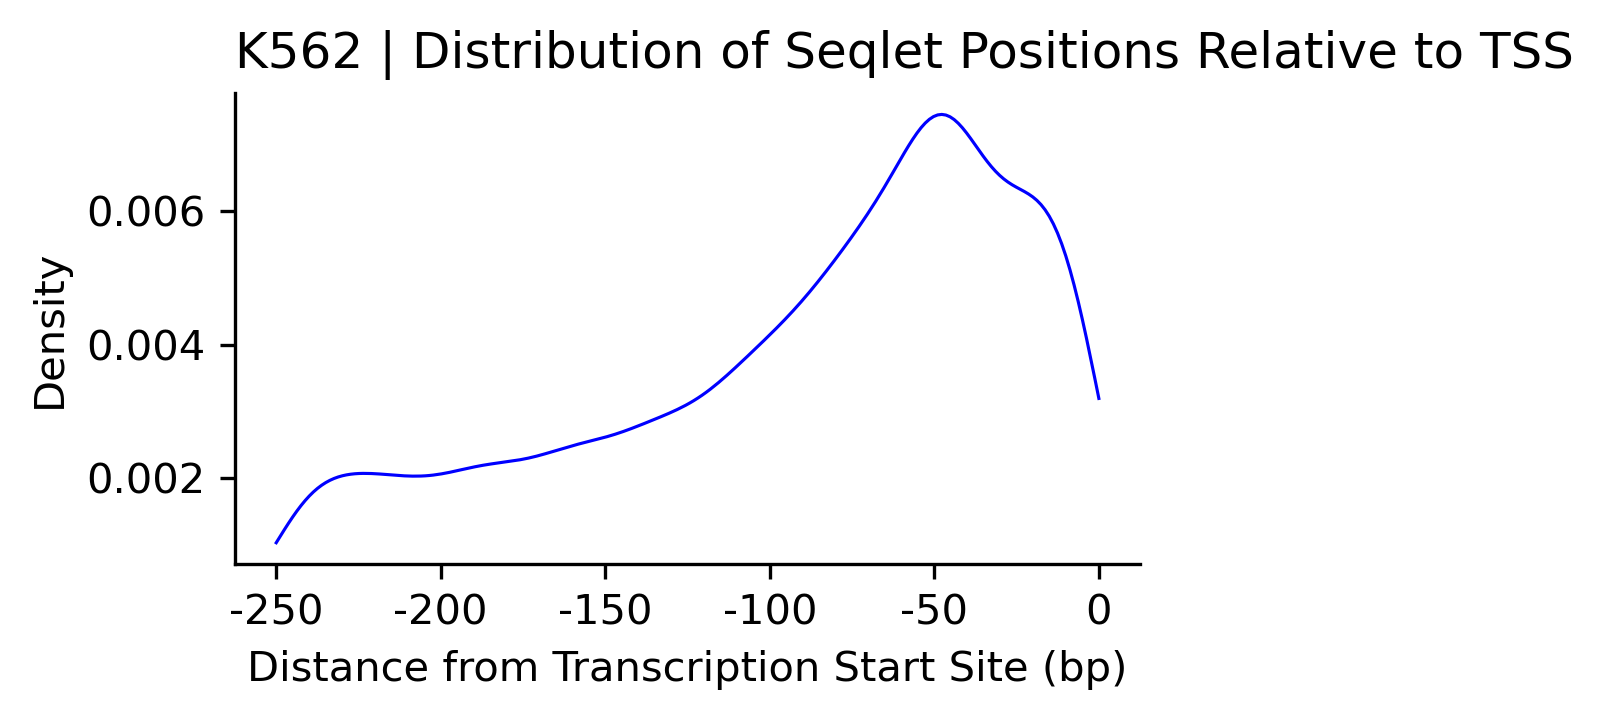

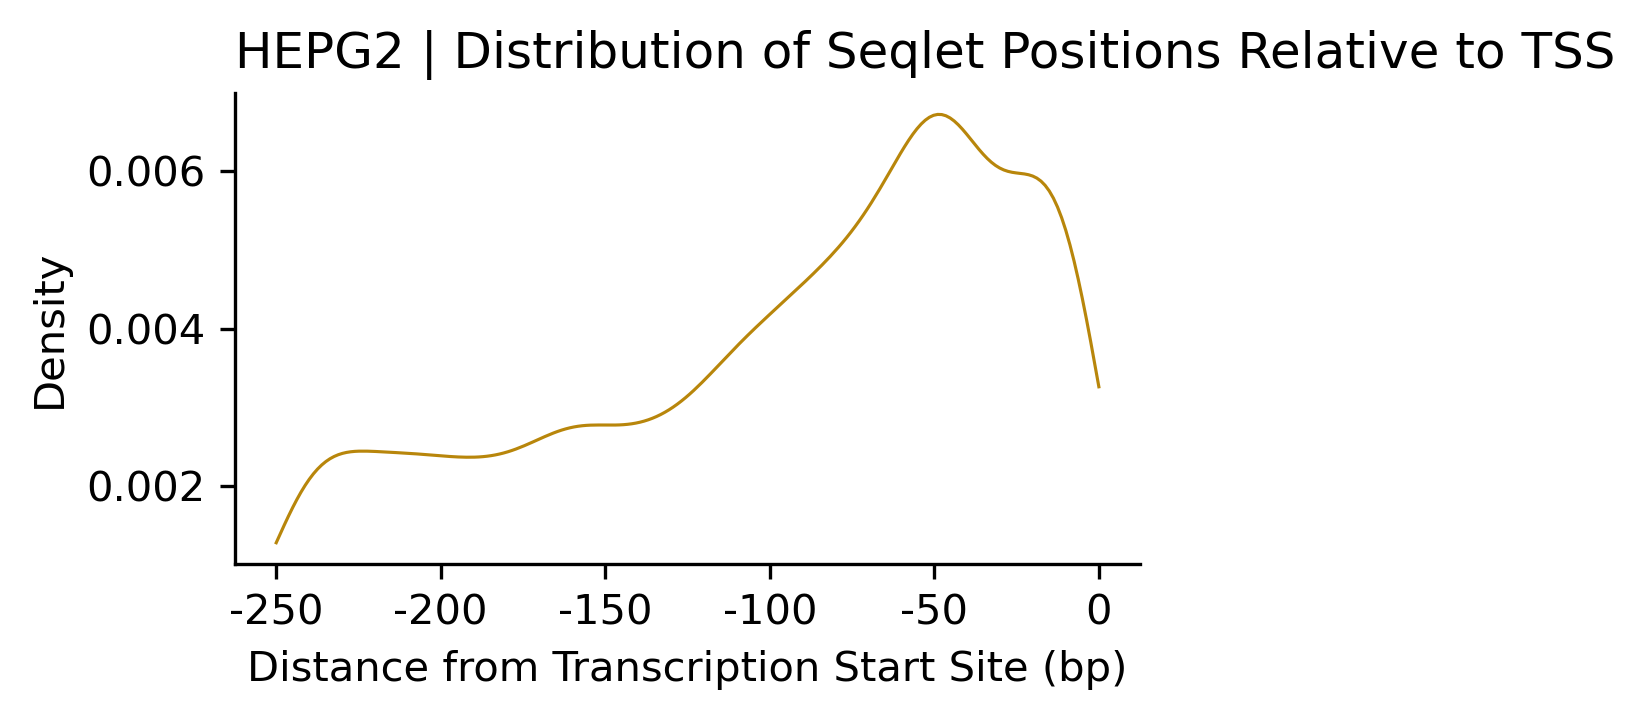

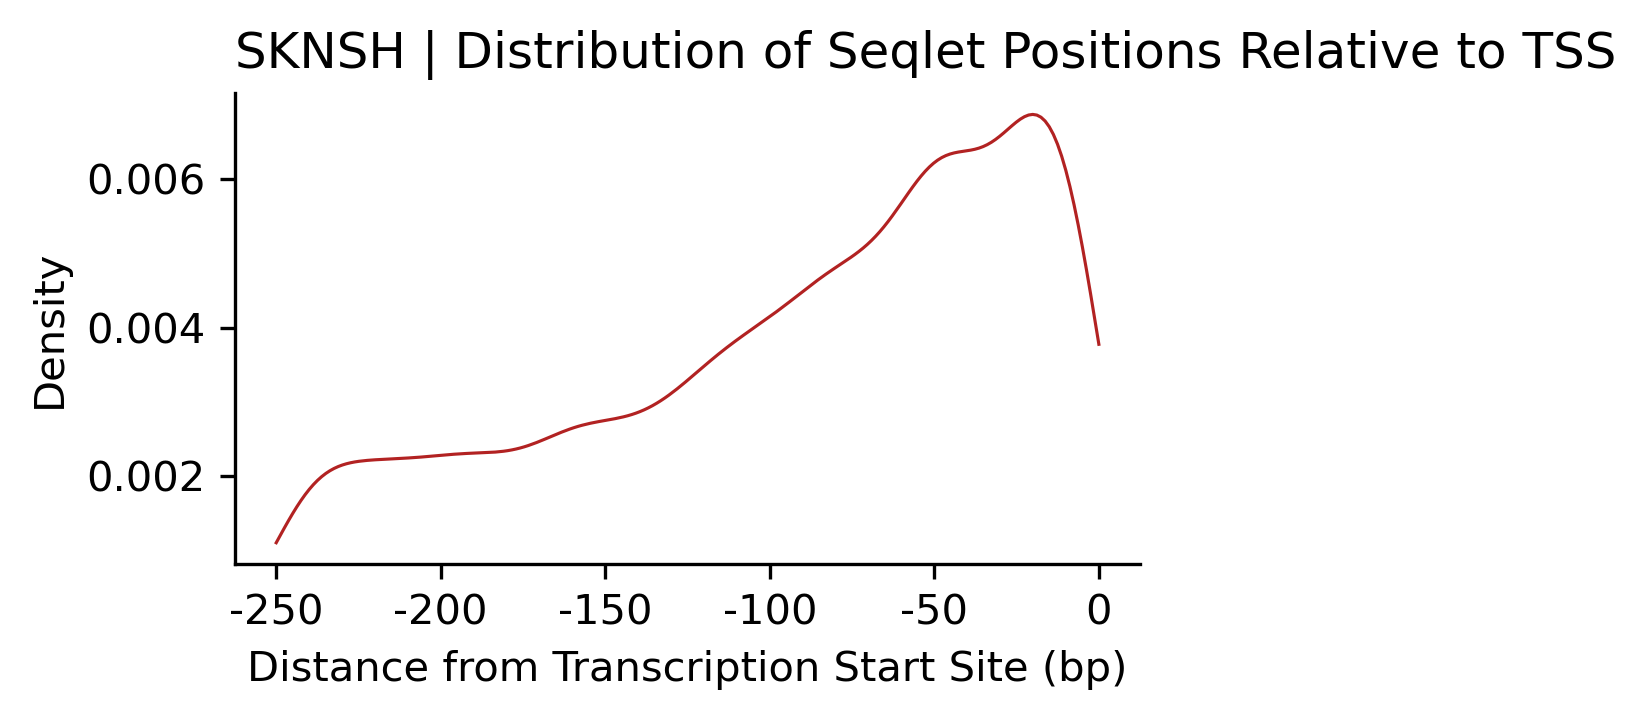

In [18]:
# generate the plots for each mpac cell type
# K562
mpac_k562_seqlet_tss_dist, mpac_k_max_loc = plot_tss_relative_seqlet_positions(
    k_mpac_collapsed,
    '../raw_data/reformatted_bed_files/gencode.v44.protein.coding.250bp.promoters.autosomes.v2.full.ID.bed',
    'k562', 
    'blue',
    'x'
)
# HepG2
mpac_hepg2_seqlet_tss_dist, mpac_h_max_loc = plot_tss_relative_seqlet_positions(
    h_mpac_collapsed,
    '../raw_data/reformatted_bed_files/gencode.v44.protein.coding.250bp.promoters.autosomes.v2.full.ID.bed',
    'hepg2', 
    'darkgoldenrod',
    'x'
)
# SKNSH
mpac_sknsh_seqlet_tss_dist, mpac_s_max_loc = plot_tss_relative_seqlet_positions(
    s_mpac_collapsed,
    '../raw_data/reformatted_bed_files/gencode.v44.protein.coding.250bp.promoters.autosomes.v2.full.ID.bed',
    'sknsh', 
    'firebrick',
    'x'
)

The max density is 0.007140050174926496
The TSS position of the max density is -50.0
The max density is 0.007142055951073184
The TSS position of the max density is -52.0


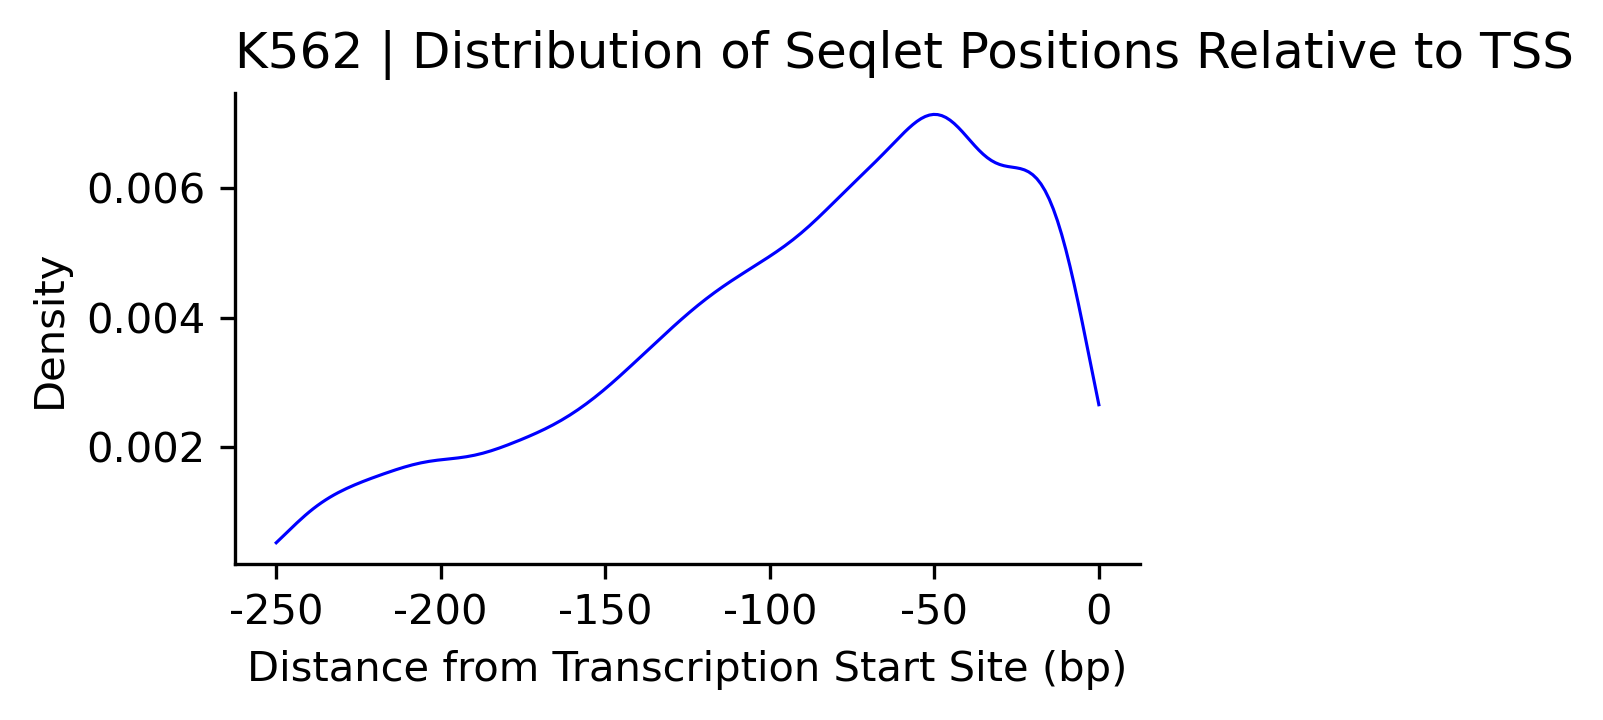

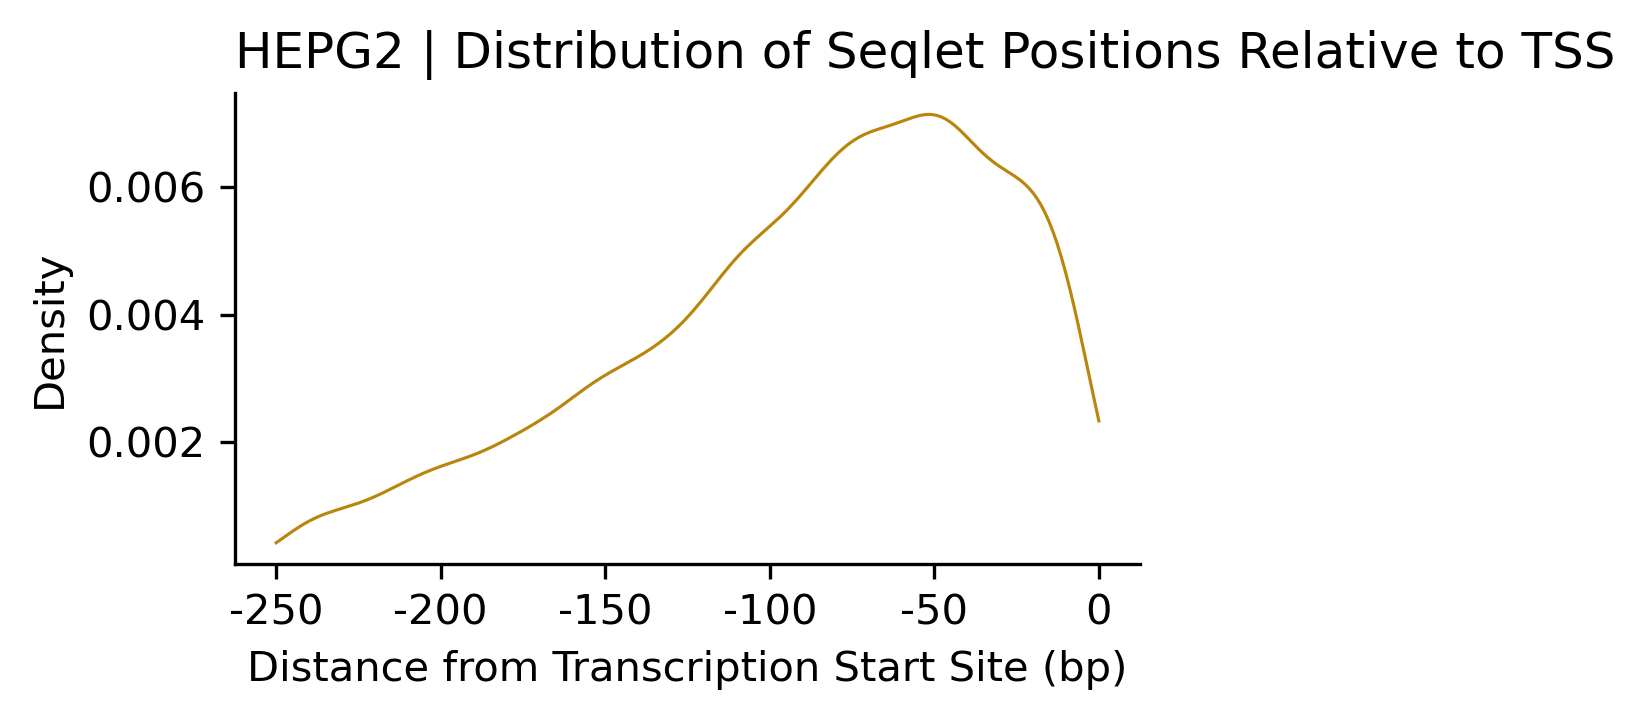

In [19]:
# generate the plots for each hepg2 cell type
# K562
parm_k562_seqlet_tss_dist, parm_k_max_loc = plot_tss_relative_seqlet_positions(
    k_parmTangermeme_collapsed,
    '../raw_data/reformatted_bed_files/gencode.v44.protein.coding.250bp.promoters.autosomes.v2.full.ID.bed',
    'k562', 
    'blue',
    'x'
)
# HepG2
parm_hepg2_seqlet_tss_dist, parm_h_max_loc = plot_tss_relative_seqlet_positions(
    h_parmTangermeme_collapsed,
    '../raw_data/reformatted_bed_files/gencode.v44.protein.coding.250bp.promoters.autosomes.v2.full.ID.bed',
    'hepg2', 
    'darkgoldenrod',
    'x'
)

The max density is 0.0085983504648593
The TSS position of the max density is -18.0


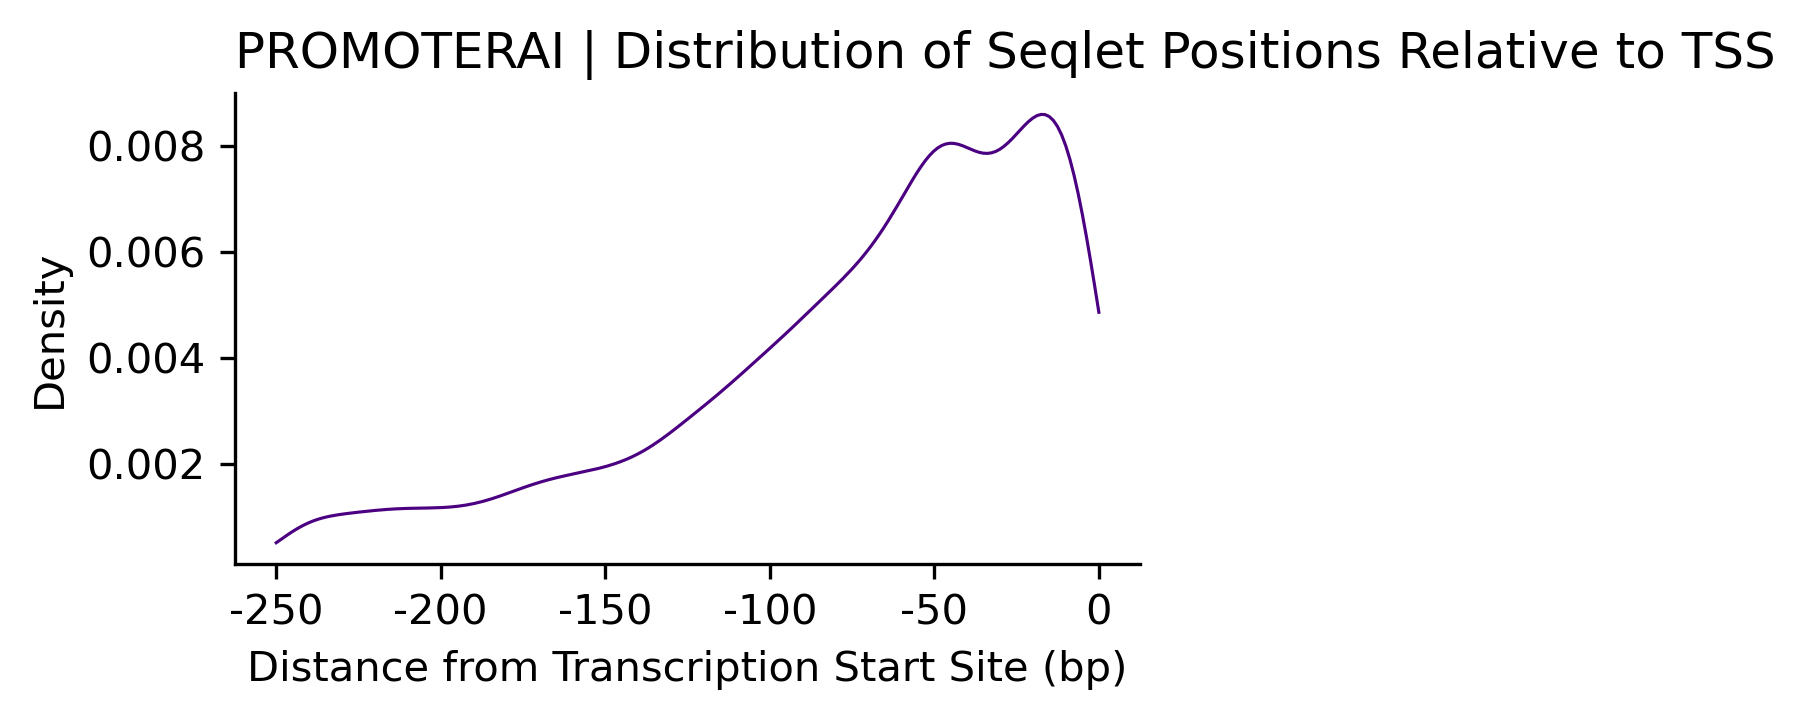

In [20]:
# generate the plots for promoterAI
# promoterAI
promoterAI_seqlet_tss_dist, proAI_max_loc = plot_tss_relative_seqlet_positions(
    promoterAI_collapsed,
    '../raw_data/reformatted_bed_files/gencode.v44.protein.coding.250bp.promoters.autosomes.v2.full.ID.bed',
    'promoterAI', 
    'indigo',
    'x'
)

NameError: name 'mpac_k_patch' is not defined

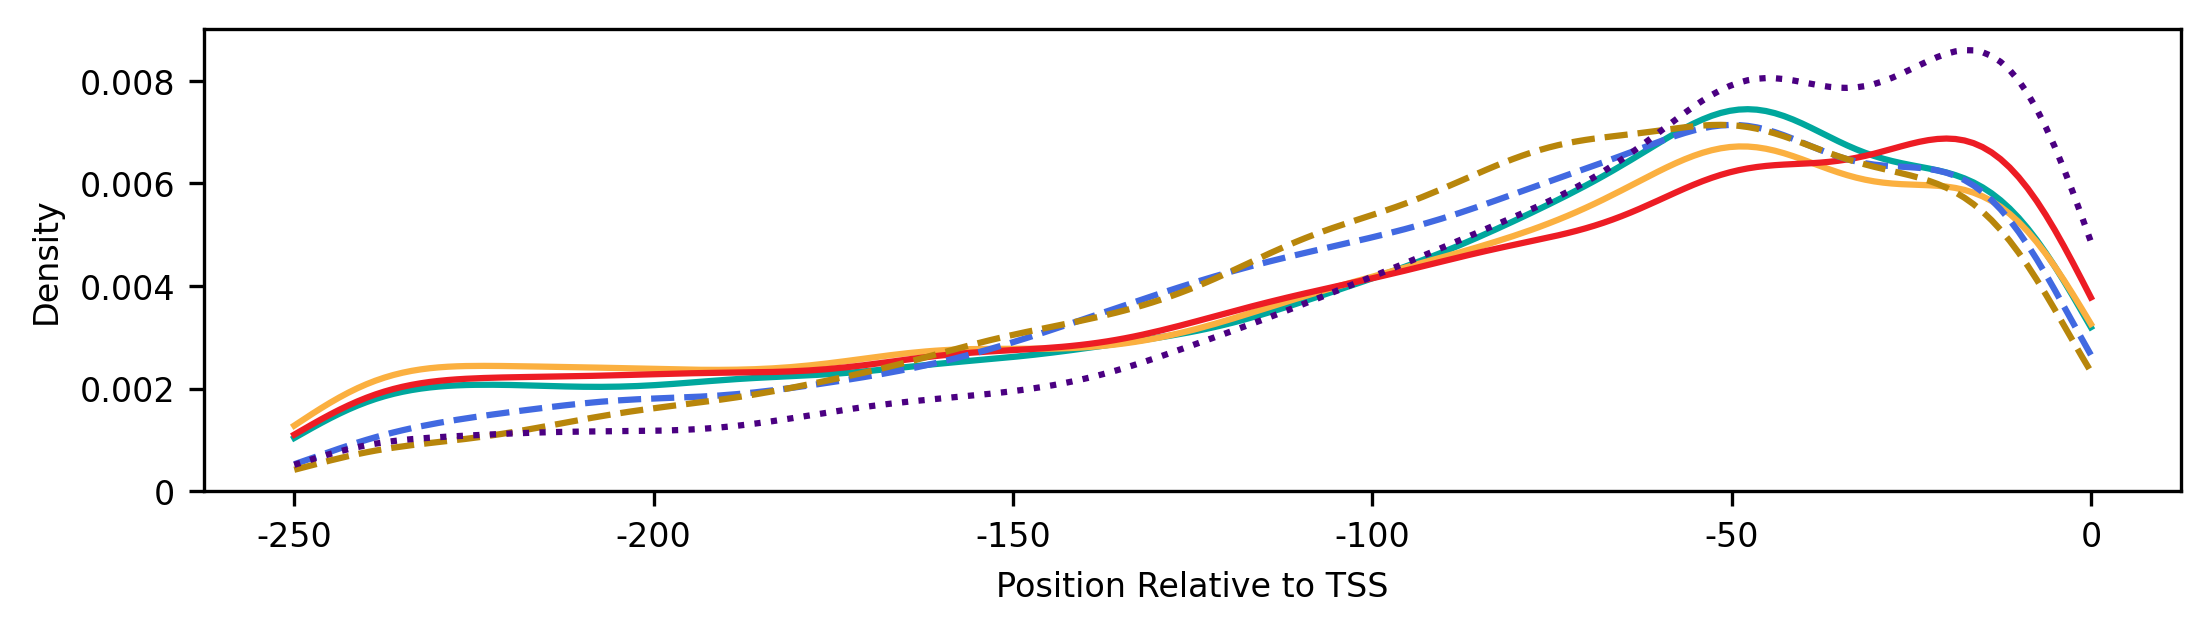

In [21]:
# plot the distributions for each method together
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.figure(figsize=(8.5, 2), dpi=300)
### mpac ###
# k562
sns.kdeplot(
    data = mpac_k562_seqlet_tss_dist,
    x = 'tss_relative_pos',
    color = '#00A79D',
    clip = ([0,250])
)
# hepg2
sns.kdeplot(
    data = mpac_hepg2_seqlet_tss_dist,
    x = 'tss_relative_pos',
    clip=([0,250]),
    color='#FBB040'
)
sns.kdeplot(
    data = mpac_sknsh_seqlet_tss_dist,
    x = 'tss_relative_pos',
    clip=([0,250]),
    color='#ED1C24'
)
### parm ###
# k562
sns.kdeplot(
    data = parm_k562_seqlet_tss_dist,
    x = 'tss_relative_pos',
    color = 'royalblue',
    linestyle='dashed',
    clip = ([0,250])
)
# hepg2
sns.kdeplot(
    data = parm_hepg2_seqlet_tss_dist,
    x = 'tss_relative_pos',
    color = 'darkgoldenrod',
    linestyle='dashed',
    clip = ([0,250])
)
### promoterAI
sns.kdeplot(
    data = promoterAI_seqlet_tss_dist,
    x = 'tss_relative_pos',
    color = 'indigo',
    linestyle=':',
    clip = ([0,250])
)
plt.xticks([0, 50, 100, 150, 200, 250],
           [-250, -200, -150, -100, -50, 0],
           fontsize=8)
plt.xlabel('Position Relative to TSS',
           fontsize=8)
plt.ylabel('Density',
           fontsize=8)
plt.yticks([0, 0.002, 0.004, 0.006, 0.008],
           [0, 0.002, 0.004, 0.006, 0.008],
           fontsize=8)
plt.legend(handles=[mpac_k_patch,
                    mpac_h_patch,
                    mpac_s_patch,
                    parm_k_patch,
                    parm_h_patch,
                    promoterAI_patch], 
                    loc='upper left',
                    fontsize='xx-small',
                    frameon=False,
                    shadow=False)
sns.despine()
#plt.savefig('../plots/seqlet_positioning_by_model.pdf', bbox_inches='tight', dpi=300)

In [23]:
# see below for the older plots (log2(OR) differenes between models)
# but let's try something new (12/14/25)
# first define a function to calculate the percent total usage for each TF method
def calcTF_usage (reformatted_bed, motif_dict, feature):
    # get the list of all TF families from Vierstra
    tfs = list(pd.Series(motif_dict.values()).unique())
    # build the DF
    mutRate = []
    TF = []
    attrib = []
    for tf in tqdm(tfs):
        # get the number of TF calls
        n_tfs = reformatted_bed['tf_family'].tolist().count(tf)
        if n_tfs == 0: # if that TF is not called append everything with a NaN
            mutRate.append(np.nan)
            TF.append(tf)
            attrib.append(np.nan)
        else:
            mutRate.append( (n_tfs / len(reformatted_bed)) * 100)
            TF.append(tf)
            attrib.append(reformatted_bed[reformatted_bed['tf_family'] == tf]['attribution'].mean()) # calculate average attribution of the TF calls
    # build DF
    df2return = pd.DataFrame({'tf_family' : TF,
                              f'percent_usage_{feature}' : mutRate,
                              f'attrib_{feature}' : attrib})
    return df2return

In [24]:
# calculate TF usage for all collapsed prediction types
dfs2merge = []
for bed, feature in zip(
    [k_mpac_collapsed, h_mpac_collapsed, s_mpac_collapsed, # mpac
    k_parmTangermeme_collapsed, h_parmTangermeme_collapsed, # PARM,
    promoterAI_collapsed], # promoterAI
    ['k562_mpac', 'hepg2_mpac', 'sknsh_mpac', 
    'k562_parmTangermeme', 'hepg2_parmTangermeme',
    'promoterAI']):
    dfs2merge.append(calcTF_usage(bed,
                                  vierstra_motif_dict,
                                  feature))
# merge DFs
all_collapsed = dfs2merge[0] # get the first df to use for merging
for df in dfs2merge[1:]:
    all_collapsed = all_collapsed.merge(df, on='tf_family')
all_collapsed.loc[:, 'mean_tf_usage'] = all_collapsed.filter([i for i in all_collapsed.keys() if 'attrib' not in i]).mean(axis=1, numeric_only=True)
# add mpac and parm mean usage
# mpac
all_collapsed.loc[:, 'mean_mpac_usage'] = [np.mean([k,h,s]) for k,h,s in zip(all_collapsed['percent_usage_k562_mpac'], all_collapsed['percent_usage_hepg2_mpac'], all_collapsed['percent_usage_sknsh_mpac'])]
# hepg2
all_collapsed.loc[:, 'mean_parm_usage'] = [np.mean([k,h]) for k,h in zip(all_collapsed['percent_usage_k562_parmTangermeme'], all_collapsed['percent_usage_hepg2_parmTangermeme'])]

  0%|          | 0/282 [00:00<?, ?it/s]

100%|██████████| 282/282 [00:00<00:00, 2041.75it/s]


In [25]:
# reformat the tf usage plot for plotting bar plots
# make a list for iterating through the usage columns
usageCols = [
    'percent_usage_k562_mpac', 'percent_usage_hepg2_mpac', 'percent_usage_sknsh_mpac', 'mean_mpac_usage', # MPAC
    'percent_usage_k562_parmTangermeme', 'percent_usage_hepg2_parmTangermeme', 'mean_parm_usage', # PARM
    'percent_usage_promoterAI' # promoterAI
]
# make a list of desired annotations
modNames = [
    'MPAC K562', 'MPAC HepG2', 'MPAC SKNSH', 'MPAC Mean', # MPAC
    'PARM K562', 'PARM HepG2', 'PARM Mean', # PARM
    'promoterAI'
]
# iterate through columns to reformat the df
dfs2cat = []
for useCol, mod in zip(usageCols, modNames):
    # filter for only the necessary columns and fill nas
    df2cat = all_collapsed.fillna(0).filter(['tf_family', useCol, 'mean_tf_usage']).copy()
    # add the model annotation
    df2cat.loc[:, 'model'] = [mod for i in range(len(df2cat))]
    # rename percent usage column
    df2cat.rename(columns={useCol: 'percent_usage'}, inplace=True)
    # append to list for final concatenation
    dfs2cat.append(df2cat)
# concatenate and sort by mean TF usage
df2plot = pd.concat(dfs2cat).sort_values(by=['mean_tf_usage'], ascending=[False]).reset_index(drop=True)
# sort by model names
df2plot['model'] = pd.Categorical(df2plot['model'], categories=[
    'MPAC K562', 'MPAC HepG2', 'MPAC SKNSH',# MPAC
    'PARM K562', 'PARM HepG2', # PARM
    'promoterAI', 'PARM Mean', 'MPAC Mean' # move means here for plotting purposes/more direct comparison to promoterAI
], ordered=True)
df2plot = df2plot.sort_values(by='model')

In [26]:
# define a palette for coloring the barplot
barPalette = {'MPAC K562' : '#00A79D',
              'MPAC HepG2' : '#FBB040',
              'MPAC SKNSH' : '#ED1C24',
              'MPAC Mean' : 'palevioletred',
              'PARM K562' : 'royalblue',
              'PARM HepG2' : 'darkgoldenrod',
              'PARM Mean' : 'thistle',
              'promoterAI' : 'indigo'}

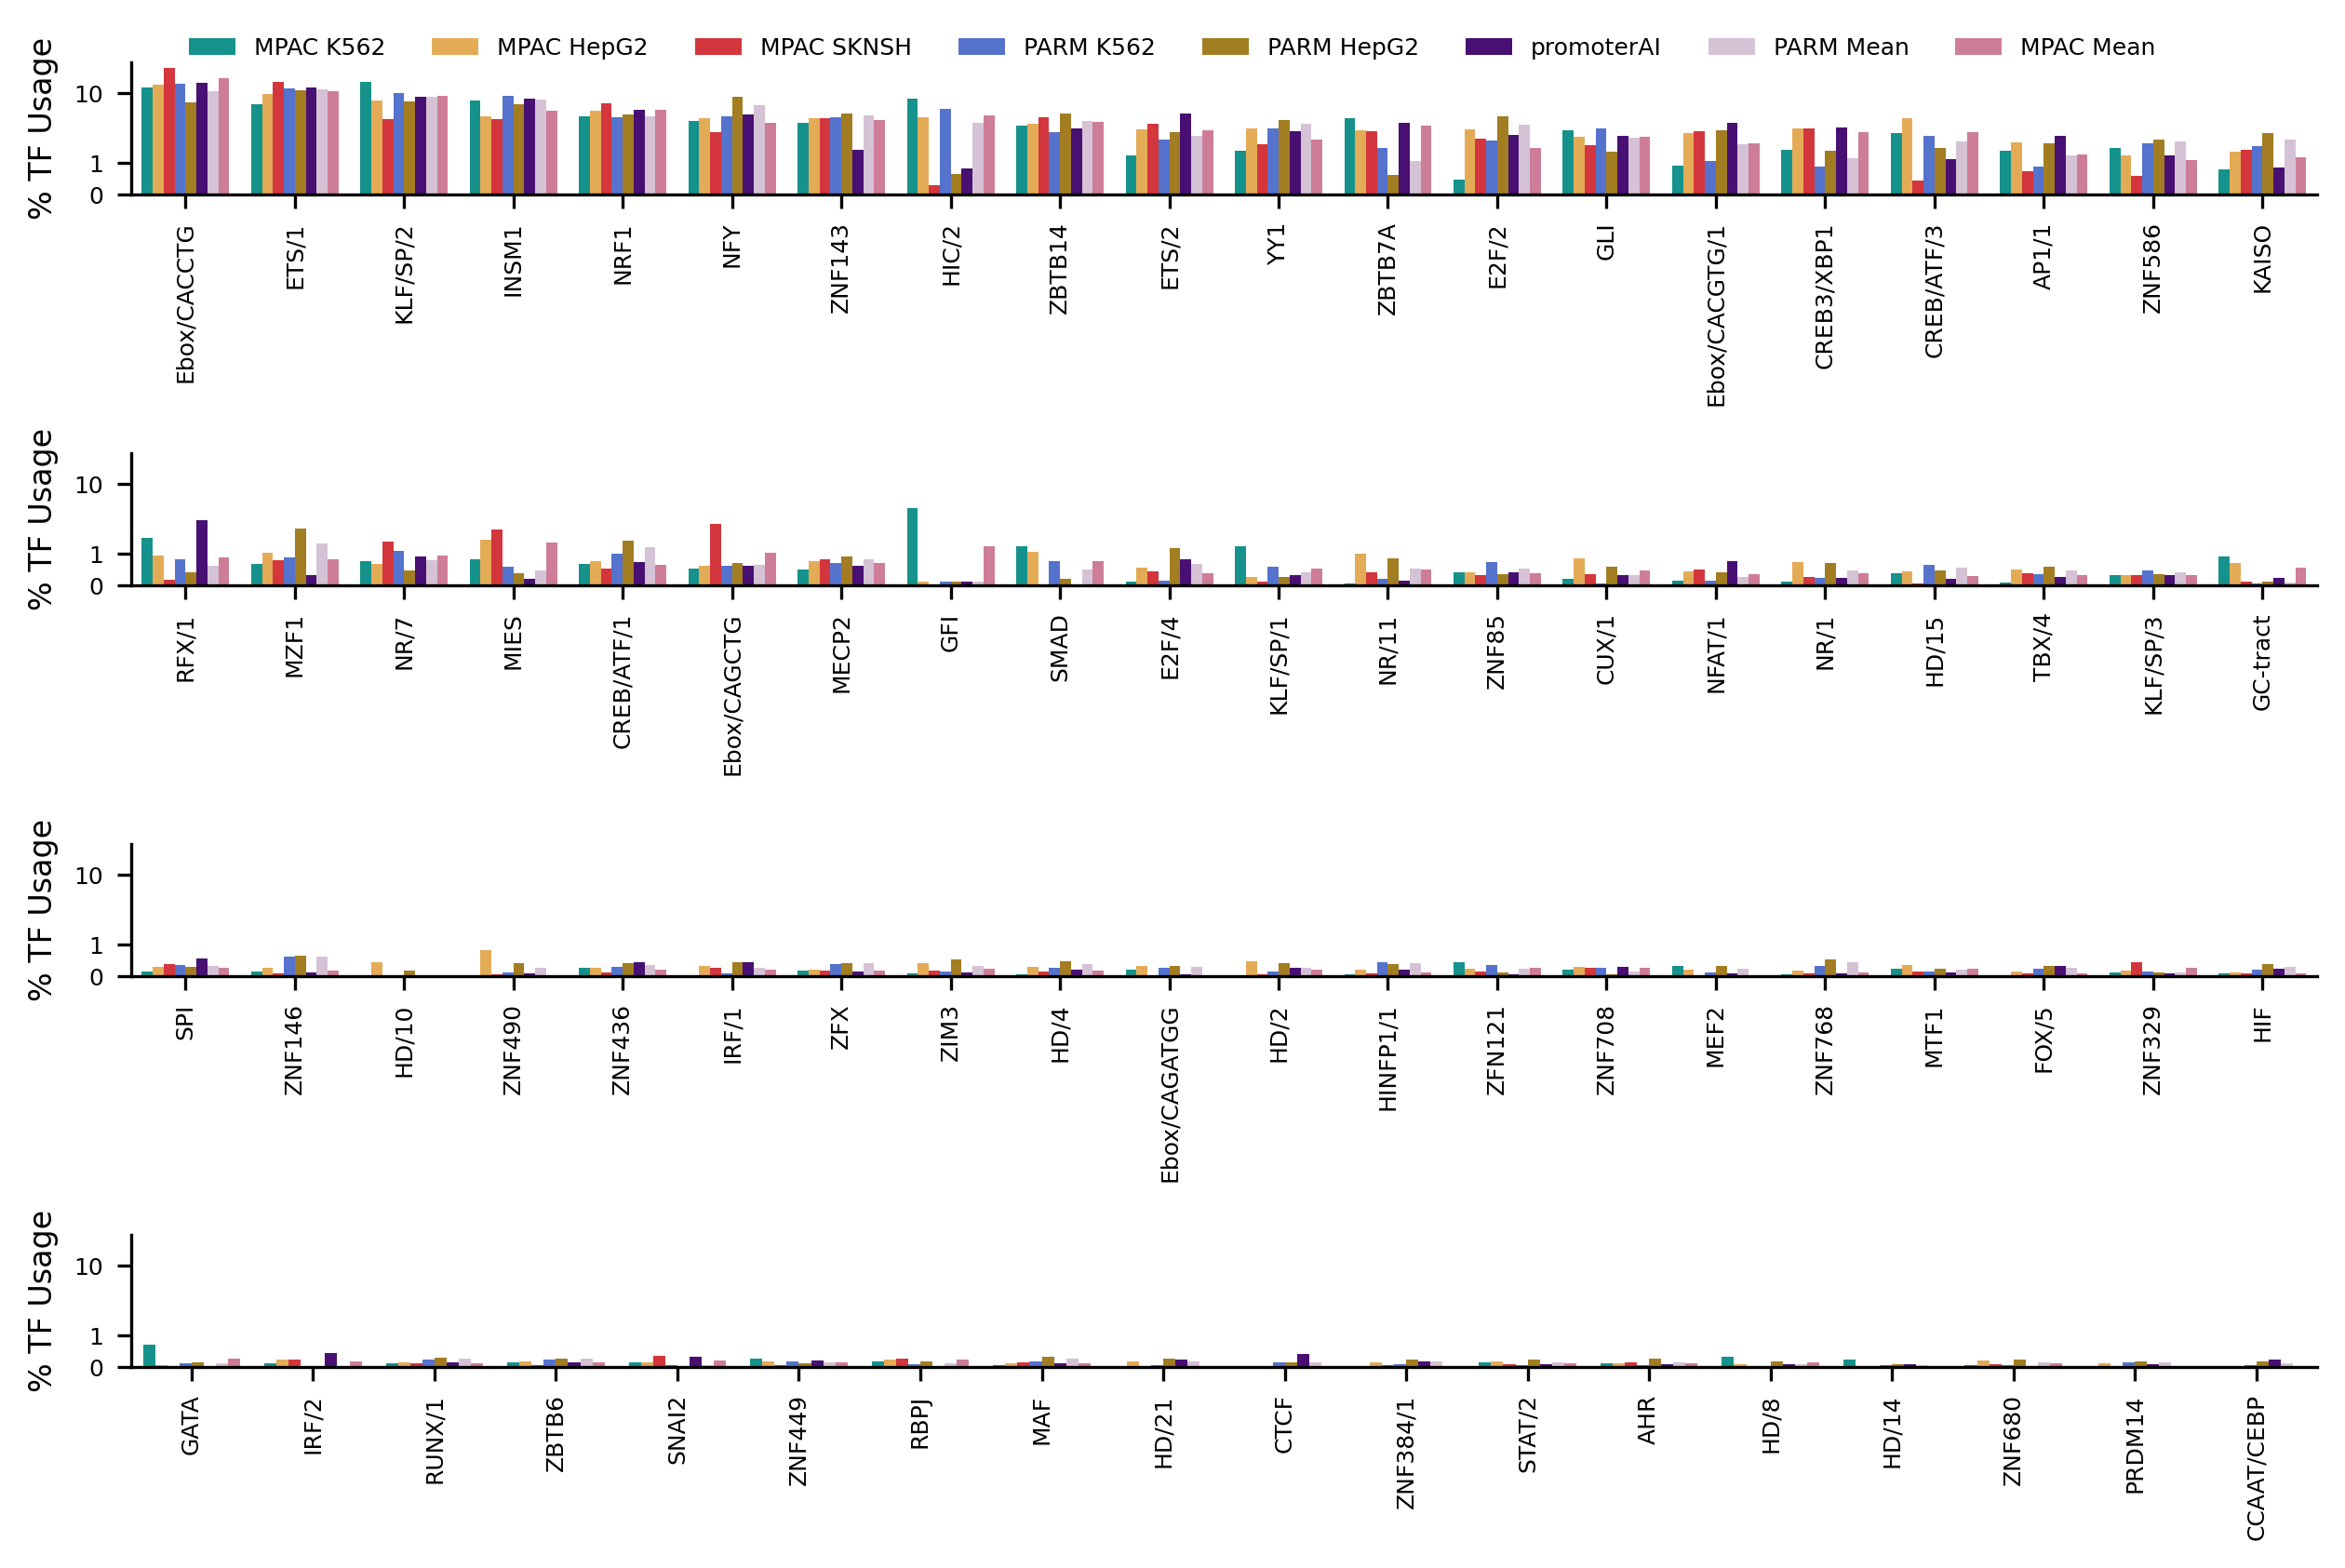

In [27]:
# get the TFs to plot but drop those with a mean usage of zero
unique_tfs = df2plot[(df2plot['mean_tf_usage'] != 0) & (df2plot['mean_tf_usage'] > 0.1)].sort_values(by='mean_tf_usage', ascending=False)['tf_family'].unique()
tfs_per_row = 20
num_rows = math.ceil(len(unique_tfs) / tfs_per_row)

# set paramaters to make them usable in illustrator
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# build fig
fig, axes = plt.subplots(num_rows, 1, figsize=(8.5, 5.5), sharey=True, dpi=300)

# Ensure axes is iterable even if there's only 1 row
if num_rows == 1: axes = [axes]

# 3. Iterate and Plot
for i, ax in enumerate(axes):
    # Determine which TFs go in this row
    start_idx = i * tfs_per_row
    end_idx = start_idx + tfs_per_row
    tf_subset = unique_tfs[start_idx:end_idx]
    
    # Filter data for just these TFs
    subset_data = all_collapsed[
        all_collapsed['tf_family'].isin(tf_subset)
    ]
    
    # Plot
    sns.barplot(
        data=df2plot,
        x='tf_family',
        y='percent_usage',
        hue='model',
        palette=barPalette,
        ax=ax,
        order=tf_subset,
    )
    
    # format axes
    ax.set_xlabel('')
    ax.set_yscale('symlog')
    ax.tick_params(axis='x', rotation=90, labelsize=6)
    ax.set_ylabel('% TF Usage', fontsize=8)
    ax.set_yticks([0, 1, 10], [0, 1, 10], fontsize=6)
    
    # Remove individual legends (we will add a global one later)
    if ax.get_legend():
        ax.get_legend().remove()

# generate legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(labels),
    fontsize=6,
    frameon=False
)
# despine plot
sns.despine()
plt.tight_layout()
# add legend to top of plot
plt.subplots_adjust(top=0.99) 
# save fig
#plt.savefig('../plots/percent_tf_usage_by_model.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [28]:
# filter for the same TFs plotted in the 
minTFs_to_plot = all_collapsed[(all_collapsed['mean_tf_usage'] != 0) & (all_collapsed['mean_tf_usage'] > 0.1)].dropna()
# calculate the tf usage correlation between usage across models
# mpac mean vs. parm mean #
# # k562
# mpac_parm_k_linReg_data = stats.linregress(
#     minTFs_to_plot['percent_usage_k562_mpac'],
#     minTFs_to_plot['percent_usage_k562_parmTangermeme']
# )
# # hepg2
# mpac_parm_h_linReg_data = stats.linregress(
#     minTFs_to_plot['percent_usage_hepg2_mpac'],
#     minTFs_to_plot['percent_usage_hepg2_parmTangermeme']
# )
# mean
# mpac_parm_mean_linReg_data = stats.linregress(
#     minTFs_to_plot['mean_mpac_usage'],
#     minTFs_to_plot['mean_parm_usage']
# )
# # mpac mean vs. promoterAI mean
# mpac_mean_proAI_linReg_data = stats.linregress(
#     minTFs_to_plot['mean_mpac_usage'],
#     minTFs_to_plot['percent_usage_promoterAI']
# )
# # parm mean vs. promoterAI mean
# parm_mean_proAI_linReg_data = stats.linregress(
#     minTFs_to_plot['mean_parm_usage'],
#     minTFs_to_plot['percent_usage_promoterAI']
# )
# calculate correlation for each comparison
# mpac mean vs. parm mean
mpac_parm_mean_corr = stats.pearsonr(
    minTFs_to_plot['mean_mpac_usage'],
    minTFs_to_plot['mean_parm_usage']
)
# mpac mean vs. proAI
mpac_proAI_corr = stats.pearsonr(
    minTFs_to_plot['mean_mpac_usage'],
    minTFs_to_plot['percent_usage_promoterAI']
)
# parm mean vs. proAI
parm_proAI_corr = stats.pearsonr(
    minTFs_to_plot['mean_parm_usage'],
    minTFs_to_plot['percent_usage_promoterAI']
)

In [29]:
len(minTFs_to_plot)

68

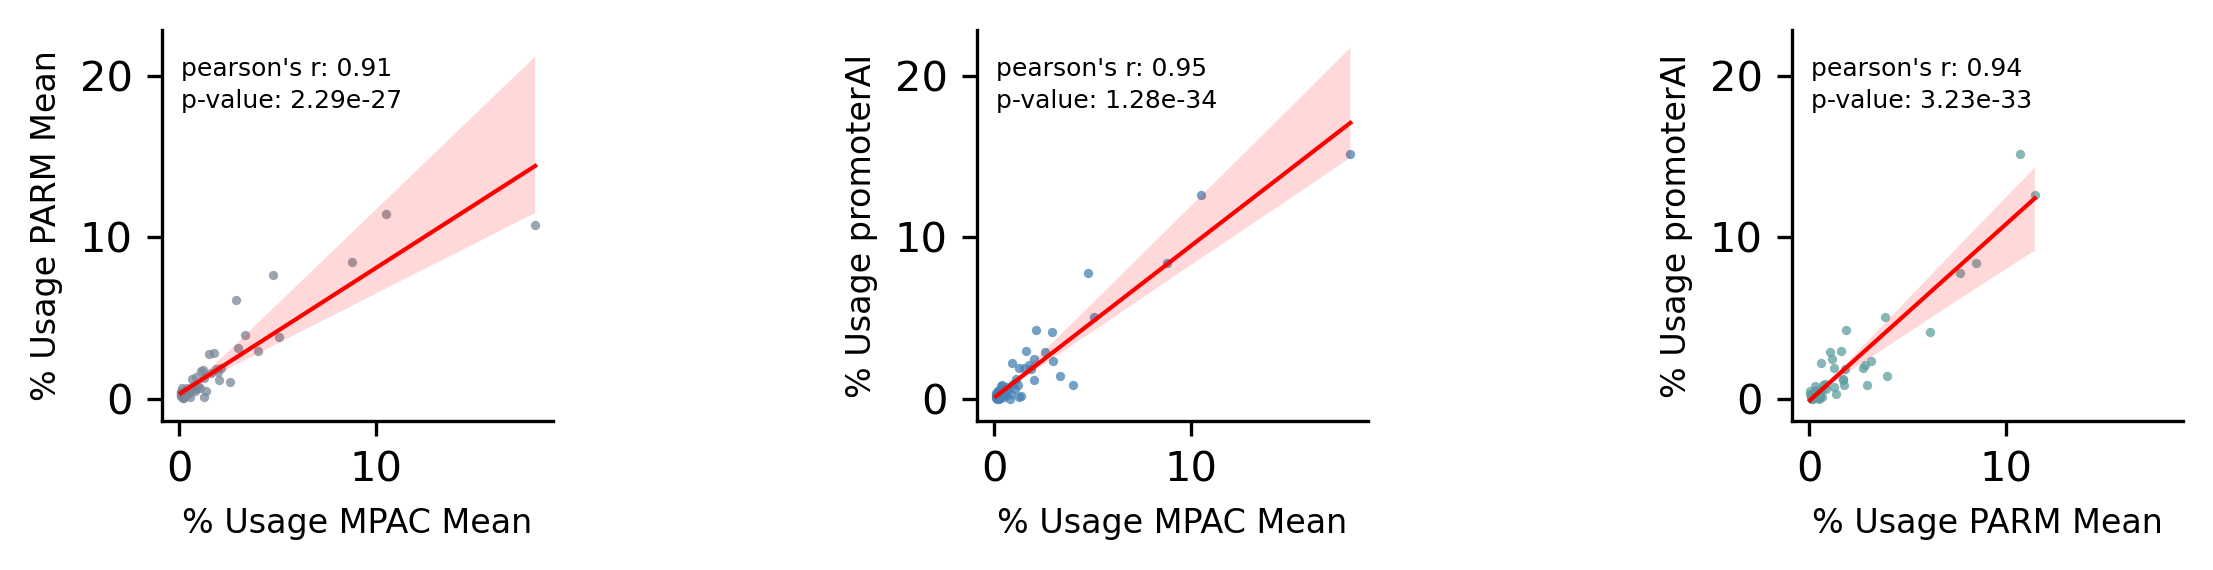

In [47]:
# plot the correlation between usage across models
f = plt.figure(figsize=(8.5, 2), dpi=300)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
gs = f.add_gridspec(1,3)
### mpac vs. PARM ###
# mean
with sns.axes_style():
    ax_01 = f.add_subplot(gs[0,0])
    ax_01.set_box_aspect(1)
    sns.regplot(
        data = minTFs_to_plot,
        x='mean_mpac_usage',
        y='mean_parm_usage',
        color='lightslategrey',
        scatter_kws={
            'linewidths' : 0,
            's' : 5,
            'alpha' : 0.75
        },
        line_kws={
            'linewidth' : 1,
            'color' : 'r',
            'alpha' : 1#0.5
        }
    )
    ax_01.set_ylabel('% Usage PARM Mean', fontsize=8)
    ax_01.set_xlabel('% Usage MPAC Mean', fontsize=8)
    plt.annotate(
        f'pearson\'s r: {round(mpac_parm_mean_corr[0],2)}',
        xy=(0.1, 20),
        fontsize=6
    )
    plt.annotate(
        f'p-value: {mpac_parm_mean_corr[-1]:.2e}',
        xy=(0.1, 18),
        fontsize=6
    )
### mpac vs. promoterAI ###
with sns.axes_style():
    ax_02 = f.add_subplot(gs[0,1], sharey=ax_01, sharex=ax_01)
    ax_02.set_box_aspect(1)
    sns.regplot(
        data = minTFs_to_plot,
        x='mean_mpac_usage',
        y='percent_usage_promoterAI',
        color='steelblue',
        scatter_kws={
            'linewidths' : 0,
            's' : 5,
            'alpha' : 0.75
        },
        line_kws={
            'linewidth' : 1,
            'color' : 'r',
            'alpha' : 1#0.5
        }
    )
    ax_02.set_ylabel('% Usage promoterAI', fontsize=8)
    ax_02.set_xlabel('% Usage MPAC Mean', fontsize=8)
    plt.annotate(
        f'pearson\'s r: {round(mpac_proAI_corr[0],2)}',
        xy=(0.1, 20),
        fontsize=6
    )
    plt.annotate(
        f'p-value: {mpac_proAI_corr[-1]:.2e}',
        xy=(0.1, 18),
        fontsize=6
    )
### parm vs. promoterAI ###
with sns.axes_style():
    ax_03 = f.add_subplot(gs[0,2], sharey=ax_01, sharex=ax_01)
    ax_03.set_box_aspect(1)
    sns.regplot(
        data = minTFs_to_plot,
        x='mean_parm_usage',
        y='percent_usage_promoterAI',
        color='cadetblue',
        scatter_kws={
            'linewidths' : 0,
            's' : 5,
            'alpha' : 0.75
        },
        line_kws={
            'linewidth' : 1,
            'color' : 'r',
            'alpha' : 1#0.5
        }
    )
    ax_03.set_ylabel('% Usage promoterAI', fontsize=8)
    ax_03.set_xlabel('% Usage PARM Mean', fontsize=8)
    plt.annotate(
        f'pearson\'s r: {round(parm_proAI_corr[0],2)}',
        xy=(0.1, 20),
        fontsize=6
    )
    plt.annotate(
        f'p-value: {parm_proAI_corr[-1]:.2e}',
        xy=(0.1, 18),
        fontsize=6
    )
plt.tight_layout()
sns.despine()
plt.savefig('../plots/percent_usage_correlation_scatters.pdf', bbox_inches='tight', dpi=300)